# Car Price Prediction


### Problem Statement
A Chinese automobile company Geely Auto aspires to enter the US market by setting up their manufacturing unit there and producing cars locally to give competition to their US and European counterparts.

They have contracted an automobile consulting company to understand the factors on which the pricing of cars depends. Specifically, they want to understand the factors affecting the pricing of cars in the American market, since those may be very different from the Chinese market. The company wants to know:

    - Which variables are significant in predicting the price of a car
    - How well those variables describe the price of a car

Based on various market surveys, the consulting firm has gathered a large dataset of different types of cars across the American market.


### Business Goal

You are required to model the price of cars with the available independent variables. It will be used by the management to understand how exactly the prices vary with the independent variables. They can accordingly manipulate the design of the cars, the business strategy etc. to meet certain price levels. Further, the model will be a good way for management to understand the pricing dynamics of a new market.

In [1]:
import warnings # Suppress warnings for cleaner output
warnings.filterwarnings('ignore') # Ignore all warnings

#importing the libraries
import numpy as np # Numerical operations
import pandas as pd # Data manipulation and analysis
import matplotlib.pyplot as plt # Plotting basic graphs
import seaborn as sns # Plotting advanced graphs

In [2]:
cars = pd.read_csv('CarPrice_Assignment.csv') # Load the dataset
pd.set_option('display.max_columns', None) 

In [3]:
cars.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
cars.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [5]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [6]:
cars.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [7]:
cars.CarName.value_counts() # Count the occurrences of each car name in the dataset

CarName
toyota corona           6
toyota corolla          6
peugeot 504             6
subaru dl               4
mitsubishi mirage g4    3
                       ..
mazda glc 4             1
mazda rx2 coupe         1
maxda glc deluxe        1
maxda rx3               1
volvo 246               1
Name: count, Length: 147, dtype: int64

In [8]:
"toyota corolla".split(' ') # Split the string "toyota corolla" into a list of words

['toyota', 'corolla']

In [9]:
"toyota corolla".split(' ')[0] # Get the first word of the string "toyota corolla"
# "audi 5000s (diesel)".split(' ')[0]

'toyota'

In [10]:
"audi 5000s (diesel)".split(' ')[0]

'audi'

In [11]:
# Splitting company name from CarName column
CompanyName = cars['CarName'].apply(lambda x : x.split(' ')[0])
cars.insert(3,"CompanyName",CompanyName) # Insert the new column into the dataframe
cars.head()

,car_ID,symboling,CarName,CompanyName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [12]:
cars.drop(['CarName'],axis=1,inplace=True) # Drop the 'CarName' column from the DataFrame
# axis=1 indicates that we are dropping a column, not a row
cars.head()

,car_ID,symboling,CompanyName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [13]:
# Display the unique company names in the 'CompanyName' column
cars.CompanyName.unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

##### Fixing invalid values
- There seems to be some spelling error in the CompanyName column.

    - `maxda` = `mazda`
    - `Nissan` = `nissan`
    - `porsche` = `porcshce`
    - `toyota` = `toyouta`
    - `vokswagen` = `volkswagen` =  `vw`

In [14]:
cars.CompanyName = cars.CompanyName.str.lower() # Convert all company names to lowercase for consistency
# This ensures that 'Nissan' and 'nissan' are treated as the same company
cars.CompanyName.unique() # Display the unique company names after converting to lowercase

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [15]:
def replace_name(old_name, new_name):
    """
    Replace old company name with new company name in the 'CompanyName' column.
    
    Parameters:
    old_name (str): The old company name to be replaced.
    new_name (str): The new company name to replace with.
    """
    cars.CompanyName.replace(old_name, new_name, inplace=True) # Replace old company name with new company name in the DataFrame

replace_name('maxda','mazda') # Replace 'maxda' with 'mazda'
replace_name('porcshce','porsche') # Replace 'porcshce' with 'porsche'
replace_name('toyouta','toyota') # Replace 'toyouta' with 'toyota'
replace_name('vokswagen','volkswagen') # Replace 'vokswagen' with 'volkswagen'
replace_name('vw','volkswagen') # Replace 'vw' with 'volkswagen'

cars.CompanyName.unique() # Display the unique company names after replacement

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

In [16]:
# Count the occurrences of each company name in the 'CompanyName' column
cars.CompanyName.value_counts()

CompanyName
toyota         32
nissan         18
mazda          17
mitsubishi     13
honda          13
volkswagen     12
subaru         12
peugeot        11
volvo          11
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
porsche         5
isuzu           4
jaguar          3
chevrolet       3
alfa-romero     3
renault         2
mercury         1
Name: count, dtype: int64

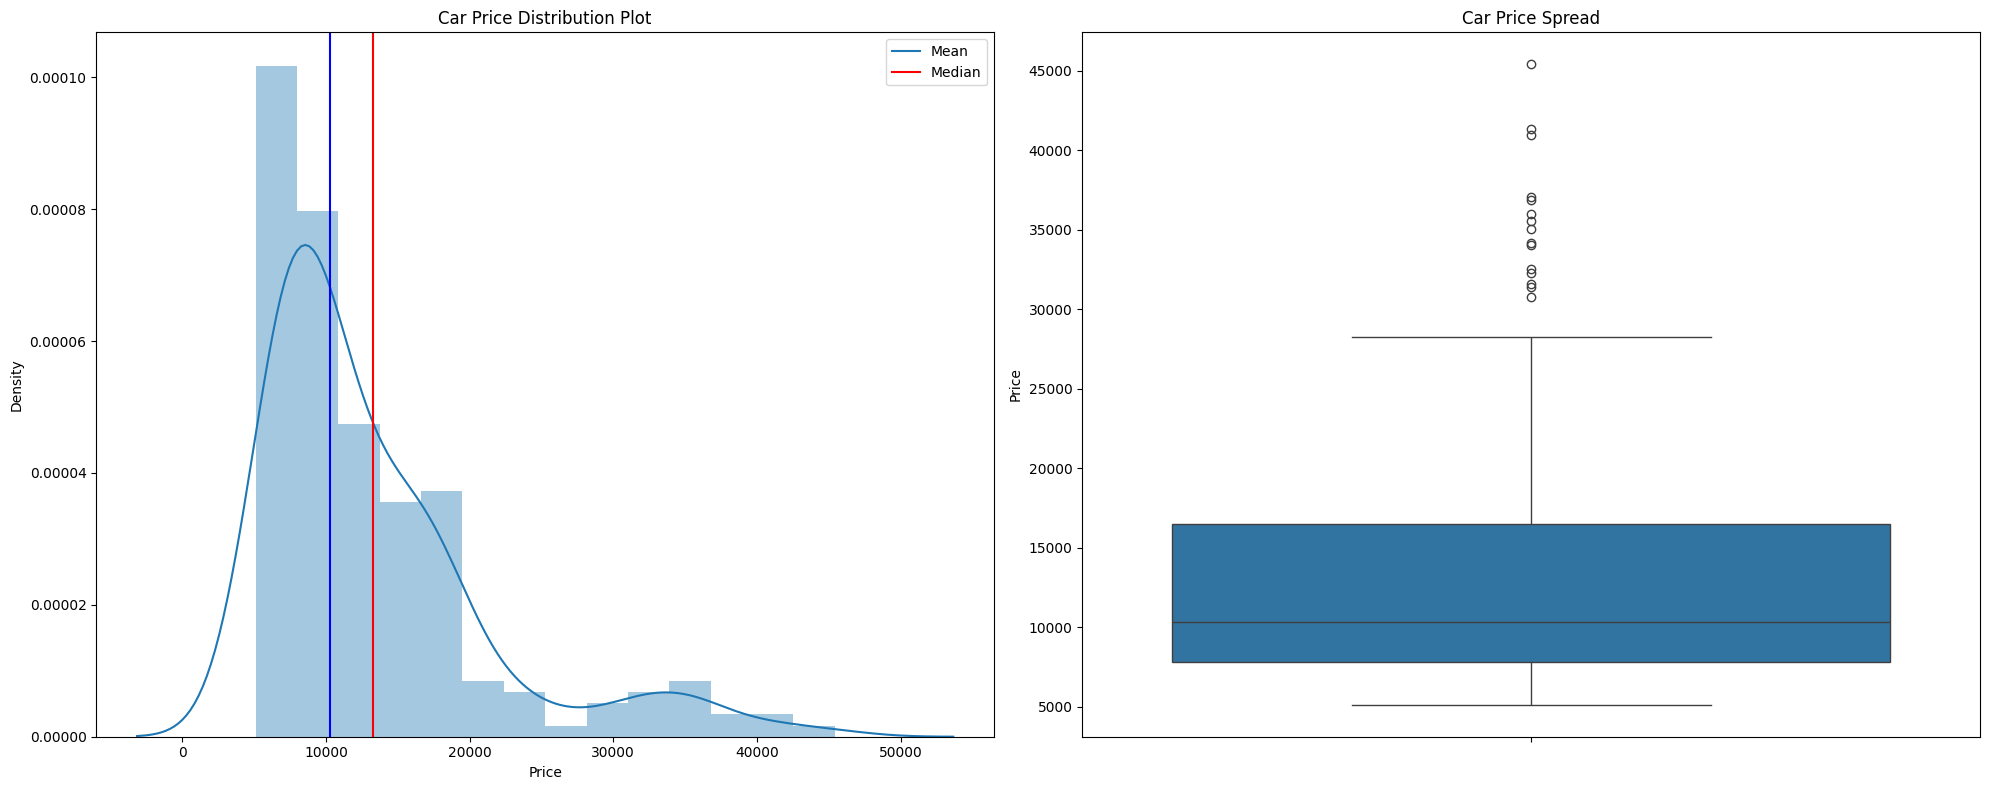

In [17]:
plt.figure(figsize=(20,8)) # Set the figure size for the plot

# Create a count plot for the 'CompanyName' column
plt.subplot(1,2,1) # 1 row, 2 columns, first subplot
plt.title('Car Price Distribution Plot')
sns.distplot(cars.price) # Plot the distribution of car prices
plt.axvline(cars.price.mean(), color="r")
plt.axvline(cars.price.median(), color="b")
plt.legend({'Mean':cars.price.mean(),'Median':cars.price.median()}) # Add a legend to the plot showing the mean and median prices
plt.xlabel('Price') # Set the x-axis label for the distribution plot
plt.ylabel('Density') # Set the y-axis label for the distribution plot

# Create a box plot for the 'price' column
plt.subplot(1,2,2) # 1 row, 2 columns, second subplot
plt.title('Car Price Spread')
sns.boxplot(y=cars.price) # Plot the spread of car prices using a box plot
plt.ylabel('Price') # Set the y-axis label for the box plot

plt.tight_layout() # Adjust the layout to prevent overlap of subplots
plt.show()

#### Inference :

1. The plot seemed to be right-skewed, meaning that the most prices in the dataset are low(Below 15,000).
2. There is a significant difference between the mean and the median of the price distribution.
3. The data points are far spread out from the mean, which indicates a high variance in the car prices.(85% of the prices are below 18,500, whereas the remaining 15% are between 18,500 and 45,400.)

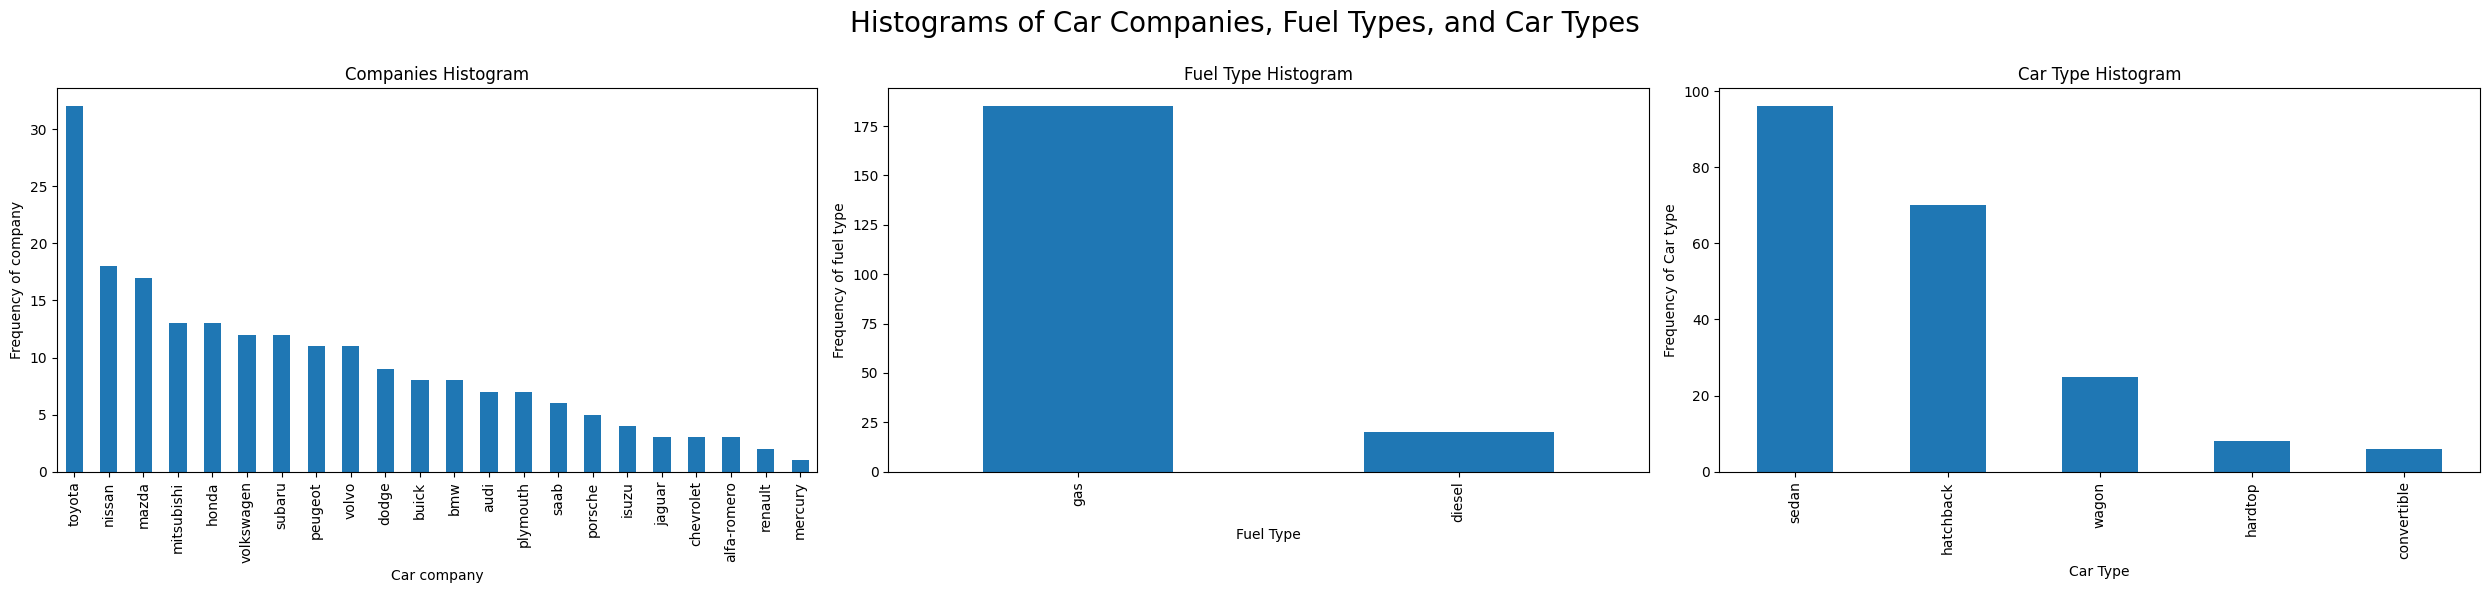

In [18]:
# Plot histograms for the 'CompanyName', 'fueltype', and 'carbody' columns
plt.figure(figsize=(25, 6)) # Set the figure size for the histograms
plt.suptitle('Histograms of Car Companies, Fuel Types, and Car Types', fontsize=20) # Set the title for the histograms

# Create subplots for each histogram
plt.subplot(1,3,1) # 1 row, 3 columns, first subplot
plt1 = cars.CompanyName.value_counts().plot(kind='bar') # Plot a bar chart for the frequency of each car company
plt.title('Companies Histogram')
plt1.set(xlabel = 'Car company', ylabel='Frequency of company') # Set the x-axis and y-axis labels for the histogram

plt.subplot(1,3,2) # 1 row, 3 columns, second subplot
plt1 = cars.fueltype.value_counts().plot(kind='bar') # Plot a bar chart for the frequency of each fuel type
plt.title('Fuel Type Histogram')
plt1.set(xlabel = 'Fuel Type', ylabel='Frequency of fuel type') # Set the x-axis and y-axis labels for the histogram

plt.subplot(1,3,3) # 1 row, 3 columns, third subplot
plt1 = cars.carbody.value_counts().plot(kind='bar') # Plot a bar chart for the frequency of each car body type
plt.title('Car Type Histogram')
plt1.set(xlabel = 'Car Type', ylabel='Frequency of Car type') # Set the x-axis and y-axis labels for the histogram

plt.tight_layout() # Adjust the layout to prevent overlap of subplots
plt.subplots_adjust(top=0.85) # Adjust the top margin to make space for the main title
# Show the histograms
plt.show()

#### Inference :

1. `Toyota` seemed to be favored car company.
2. Number of `gas` fueled cars are more than `diesel`.
3. `sedan` is the top car type prefered.

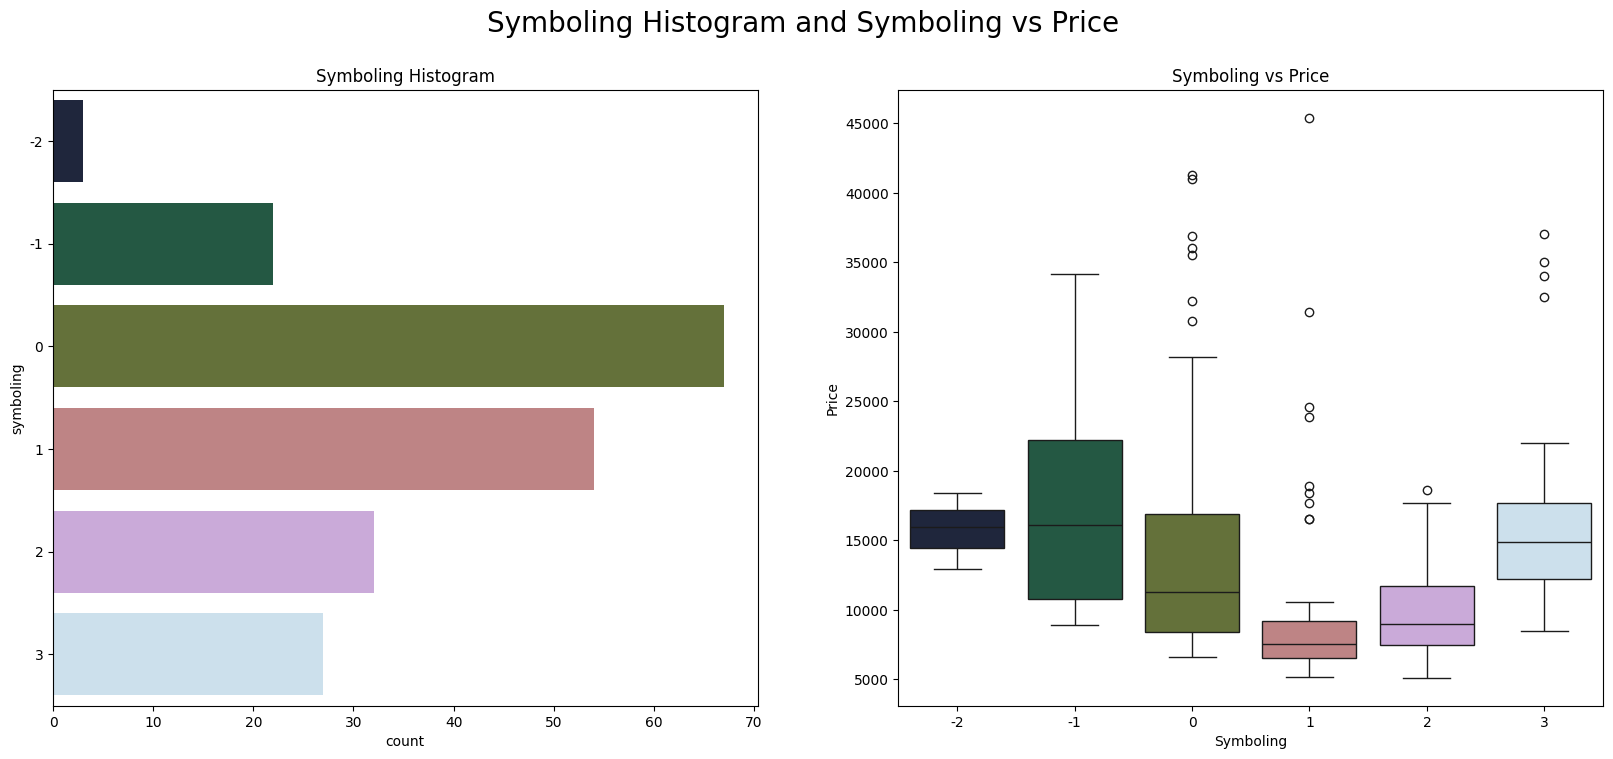

In [19]:
# Plotting the 'symboling' column and its relationship with 'price'
plt.figure(figsize=(20,8)) # Set the figure size for the plot
plt.suptitle('Symboling Histogram and Symboling vs Price', fontsize=20) # Set the main title for the plot

plt.subplot(1,2,1) # 1 row, 2 columns, first subplot
plt.title('Symboling Histogram')
sns.countplot(cars.symboling.astype('category'), palette=("cubehelix")) # Plot a count plot for the 'symboling' column, treating it as a categorical variable

plt.subplot(1,2,2) # 1 row, 2 columns, second subplot   
plt.title('Symboling vs Price') 
sns.boxplot(x=cars.symboling, y=cars.price, palette=("cubehelix")) # Plot a box plot to show the relationship between 'symboling' and 'price'
plt.xlabel('Symboling') # Set the x-axis label for the box plot
plt.ylabel('Price') # Set the y-axis label for the box plot

plt.show()

#### Inference :

1. It seems that the symboling with `0` and `1` values have high number of rows (i.e. They are most sold.)
2. The cars with `-1` symboling seems to be high priced (as it makes sense too, insurance risk rating -1 is quite good). But it seems that symboling with `3` value has the price range similar to `-2` value. There is a dip in price at symboling `1`.

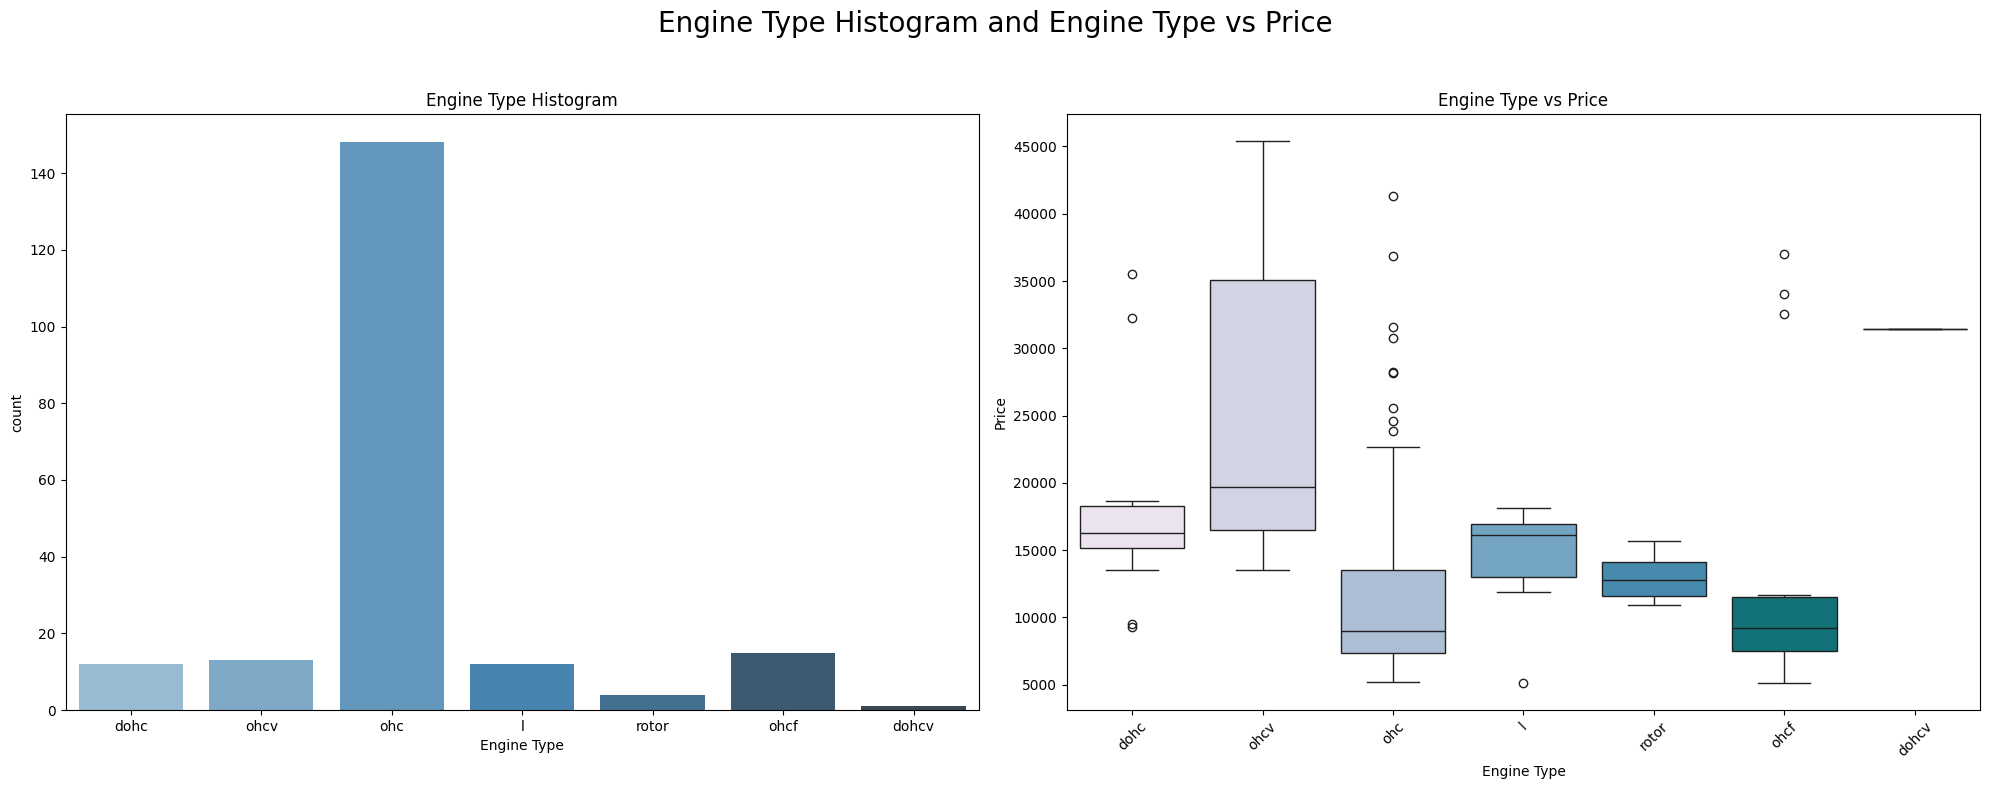

In [20]:
# Plotting the 'enginetype' column and its relationship with 'price'
plt.figure(figsize=(20, 8))
plt.suptitle('Engine Type Histogram and Engine Type vs Price', fontsize=20)

# Create subplots for the histograms and box plots
plt.subplot(1, 2, 1) # 1 row, 2 columns, first subplot
plt.xlabel('Engine Type') # Set the x-axis label for the histogram
plt.title('Engine Type Histogram')
sns.countplot(data=cars, x='enginetype', palette="Blues_d") # Plot a count plot for the 'enginetype' column, treating it as a categorical variable

plt.subplot(1, 2, 2) # 1 row, 2 columns, second subplot
plt.xlabel('Engine Type') # Set the x-axis label for the box plot
plt.ylabel('Price') # Set the y-axis label for the box plot
plt.xticks(rotation=45) # Rotate the x-axis labels for better readability
plt.title('Engine Type vs Price')
sns.boxplot(data=cars, x='enginetype', y='price', palette="PuBuGn") # Plot a box plot to show the relationship between 'enginetype' and 'price'

plt.tight_layout() # Adjust the layout to prevent overlap of subplots
plt.subplots_adjust(top=0.85) # Adjust the top margin to make space for the main title
# Show the plots
plt.show()


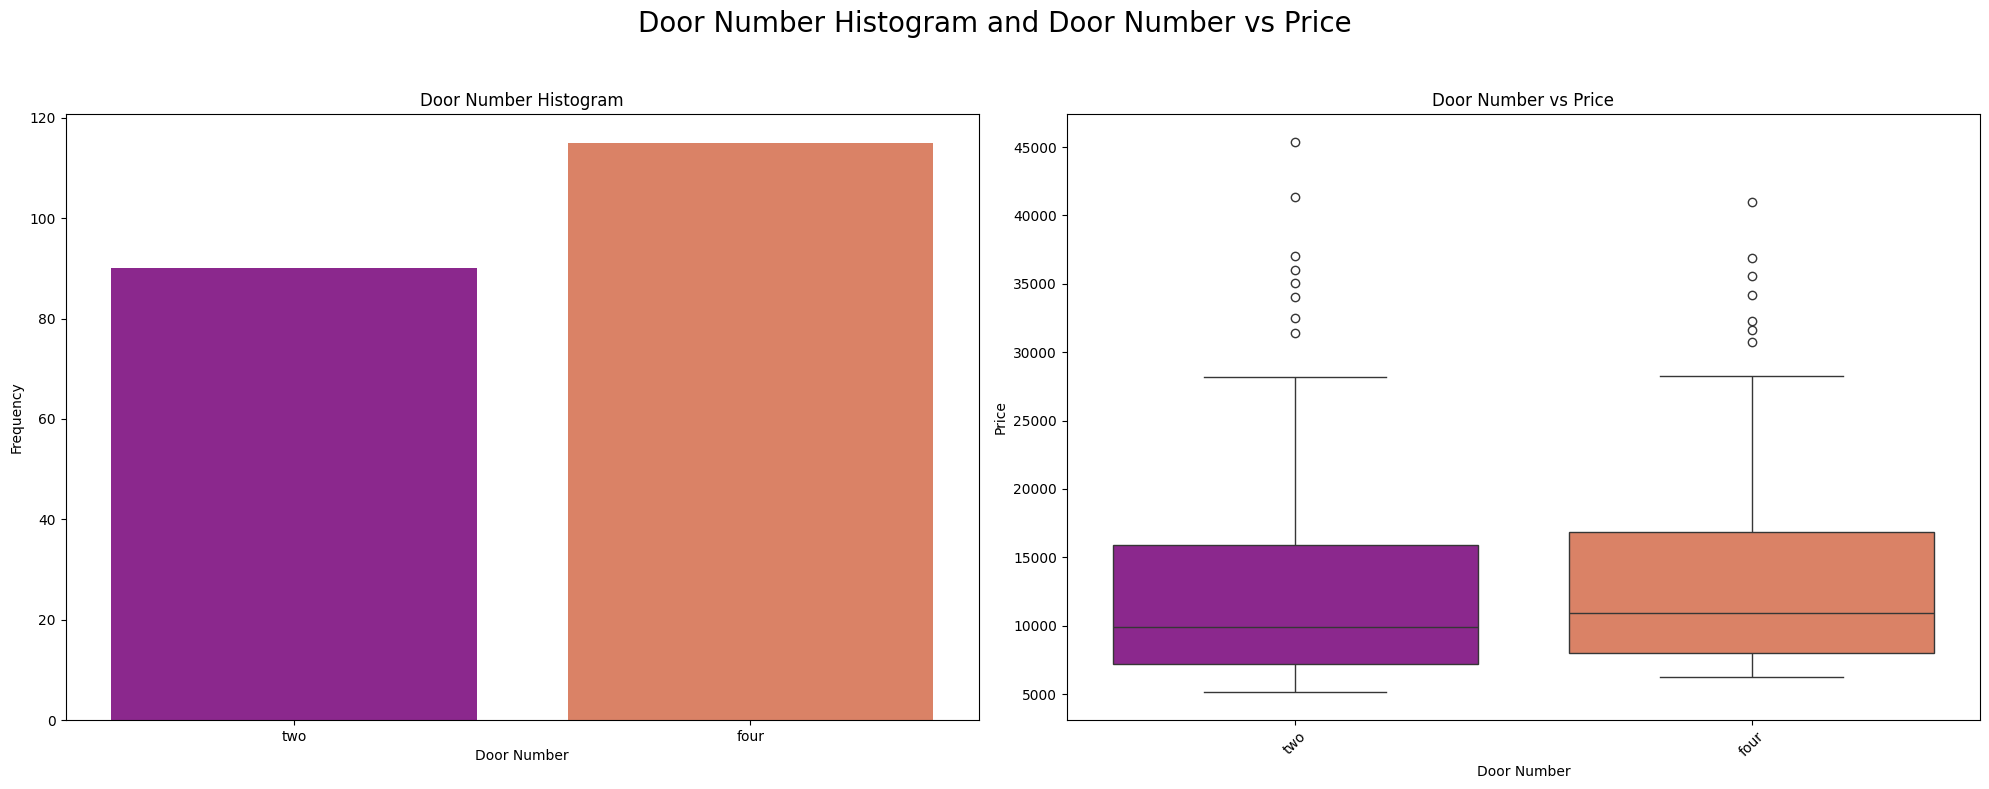

In [21]:
# Plotting the 'doornumber' column and its relationship with 'price'
plt.figure(figsize=(20, 8)) # Set the figure size for the plot
plt.suptitle('Door Number Histogram and Door Number vs Price', fontsize=20) # Set the main title for the plot

plt.subplot(1, 2, 1) # 1 row, 2 columns, first subplot
plt.title('Door Number Histogram') 
sns.countplot(data=cars, x='doornumber', palette="plasma") # Plot a count plot for the 'doornumber' column, treating it as a categorical variable
plt.xlabel('Door Number') # Set the x-axis label for the histogram
plt.ylabel('Frequency') # Set the y-axis label for the histogram

plt.subplot(1, 2, 2) # 1 row, 2 columns, second subplot
plt.xlabel('Door Number') # Set the x-axis label for the box plot
plt.ylabel('Price') # Set the y-axis label for the box plot
plt.xticks(rotation=45) # Rotate the x-axis labels for better readability
plt.title('Door Number vs Price') # Plot a box plot to show the relationship between 'doornumber' and 'price'
sns.boxplot(data=cars, x='doornumber', y='price', palette="plasma") # Plot a box plot to show the relationship between 'doornumber' and 'price'

plt.tight_layout() # Adjust the layout to prevent overlap of subplots
plt.subplots_adjust(top=0.85) # Adjust the top margin to make space for the main title
# Show the plots
plt.show()

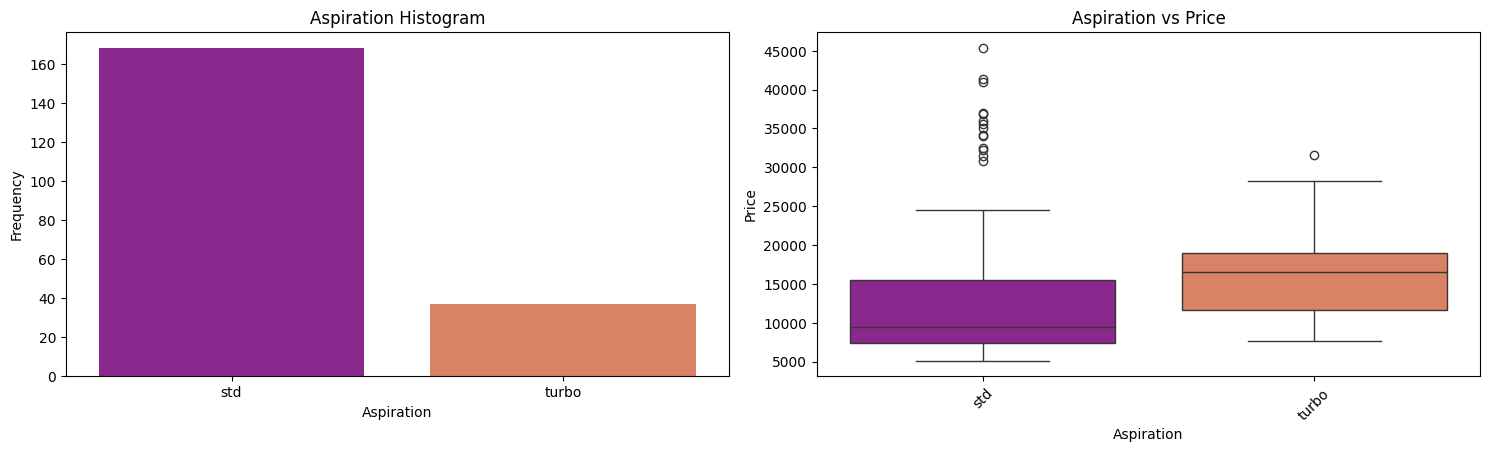

In [22]:
plt.figure(figsize=(15, 5)) # Set the figure size for the plot

plt.subplot(1, 2, 1) # 1 row, 2 columns, first subplot
plt.title('Aspiration Histogram')
sns.countplot(data=cars, x='aspiration', palette="plasma") # Plot a count plot for the 'aspiration' column, treating it as a categorical variable
plt.xlabel('Aspiration') # Set the x-axis label for the histogram
plt.ylabel('Frequency') # Set the y-axis label for the histogram

plt.subplot(1, 2, 2) # 1 row, 2 columns, second subplot
plt.title('Aspiration vs Price')
sns.boxplot(data=cars, x='aspiration', y='price', palette="plasma") # Plot a box plot to show the relationship between 'aspiration' and 'price'
plt.xlabel('Aspiration') # Set the x-axis label for the box plot
plt.ylabel('Price') # Set the y-axis label for the box plot
plt.xticks(rotation=45) # Rotate the x-axis labels for better readability

plt.tight_layout() # Adjust the layout to prevent overlap of subplots
plt.subplots_adjust(top=0.85) # Adjust the top margin to make space for the main title
# Show the plots
plt.show()


#### Inference :

1. `doornumber` variable is not affacting the price much. There is no sugnificant difference between the categories in it.
2. It seems aspiration with `turbo` have higher price range than the `std`(though it has some high values outside the whiskers.)

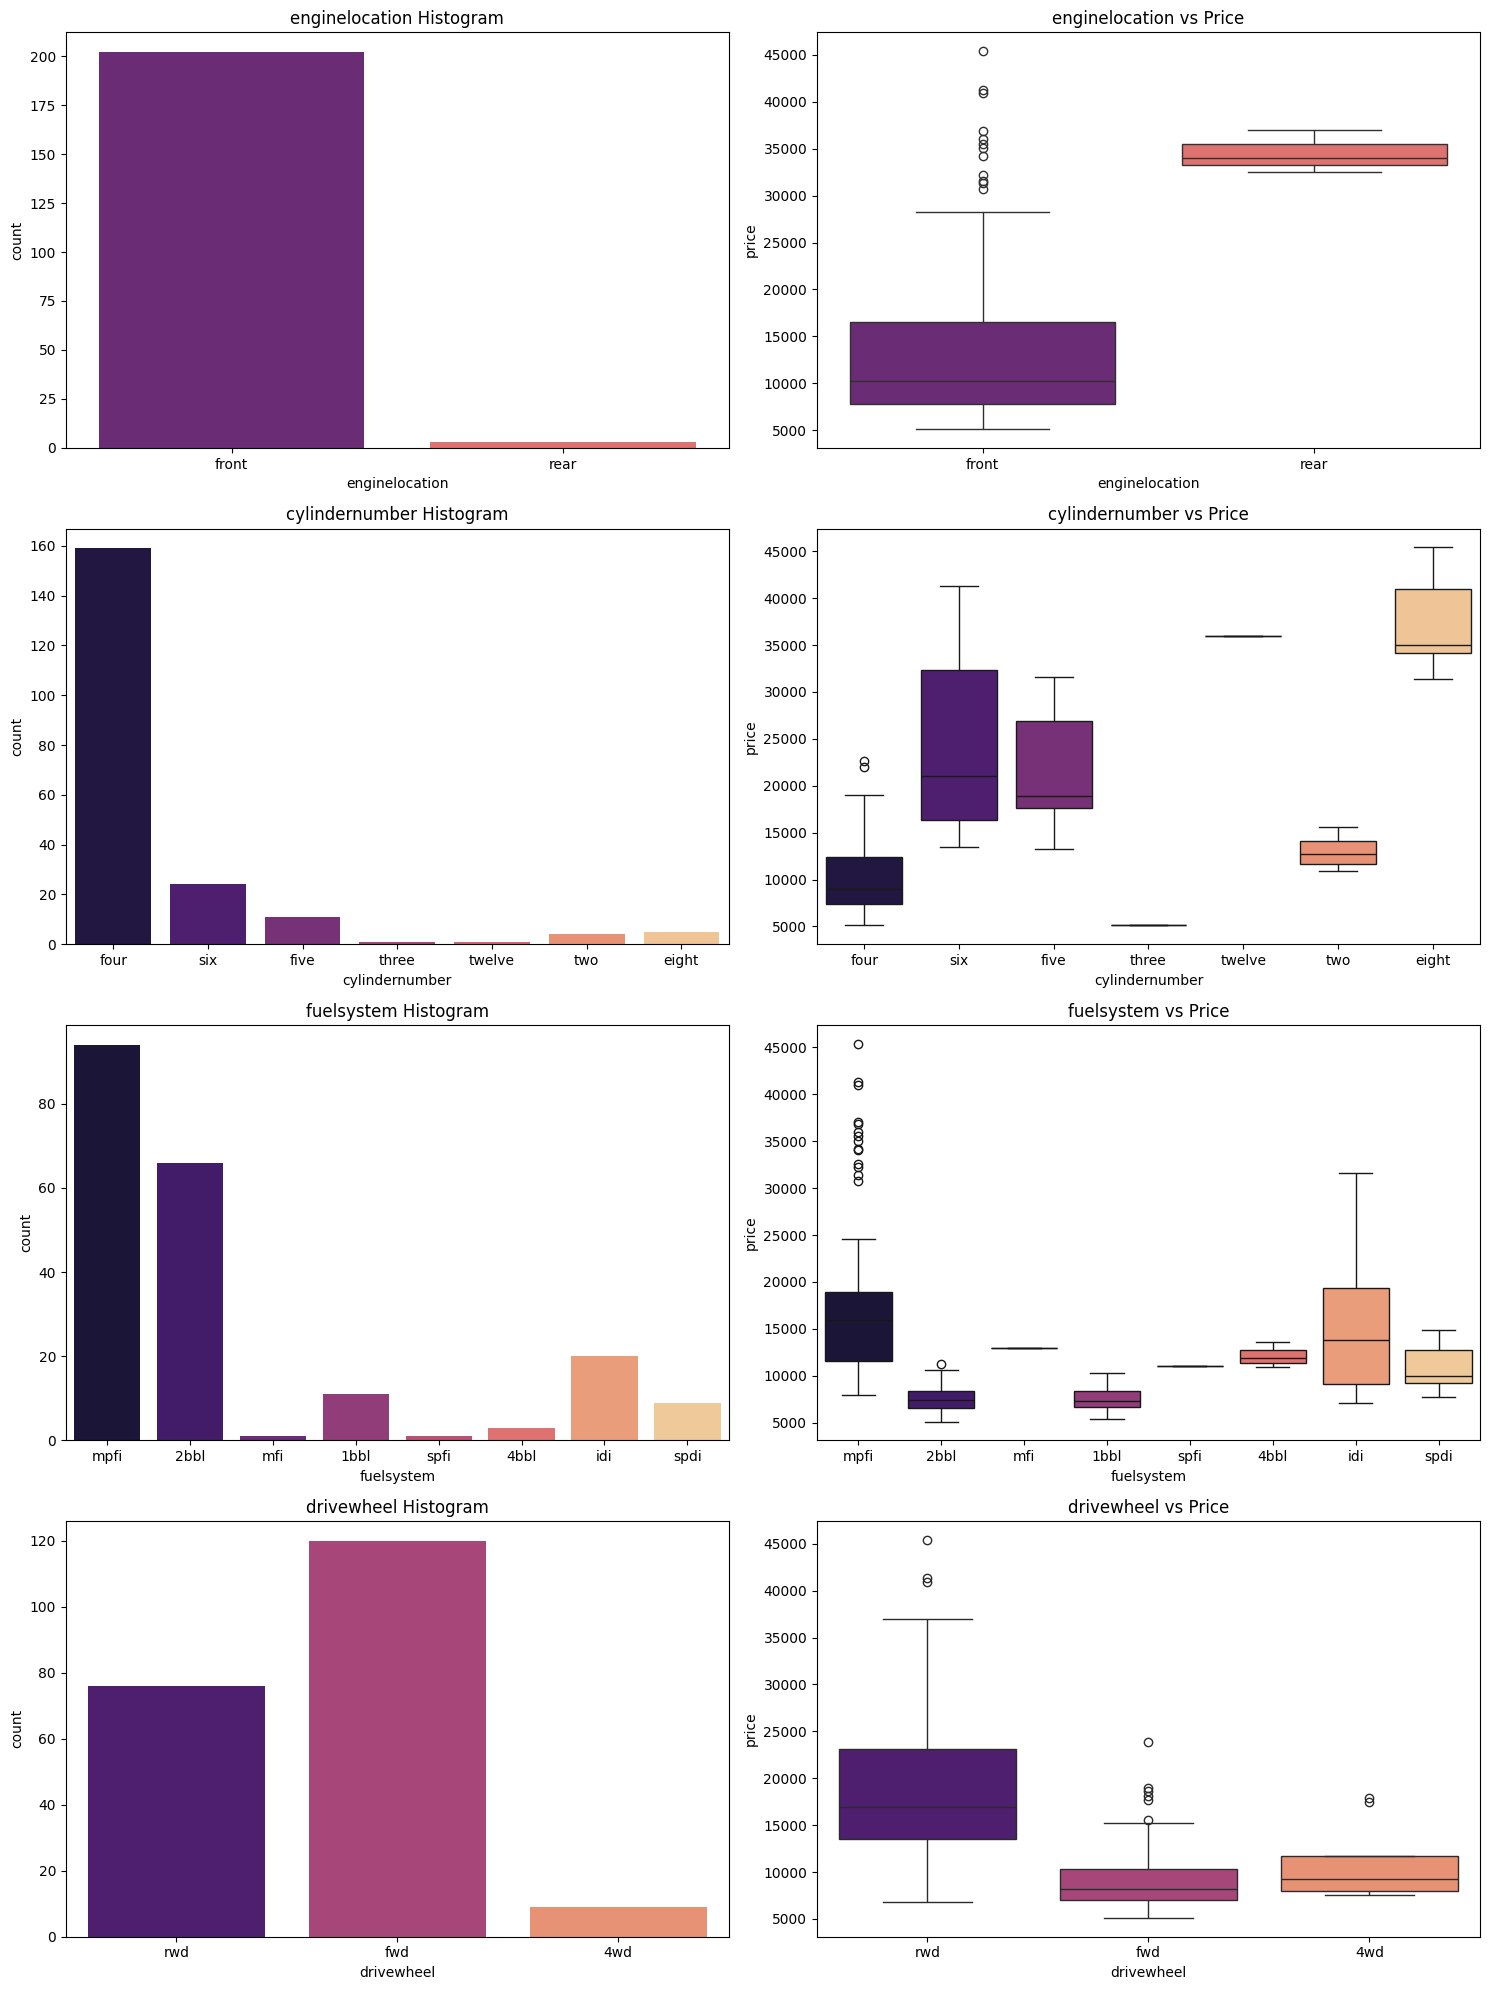

In [23]:
# Plotting the 'enginelocation', 'cylindernumber', 'fuelsystem', and 'drivewheel' columns
def plot_count(x, fig): # Function to plot count and box plots for a given column
    plt.subplot(4, 2, fig)
    plt.title(x + ' Histogram')
    sns.countplot(data=cars, x=x, palette="magma")
    plt.subplot(4, 2, (fig + 1))
    plt.title(x + ' vs Price')
    sns.boxplot(data=cars, x=x, y='price', palette="magma")

plt.figure(figsize=(15, 20))

plot_count('enginelocation', 1)
plot_count('cylindernumber', 3)
plot_count('fuelsystem', 5)
plot_count('drivewheel', 7)

plt.tight_layout()
plt.show()


#### Inference :

1. Very few datapoints for `enginelocation` categories to make an inference.
2. Most common number of cylinders are `four`, `six` and `five`. Though `eight` cylinders have the highest price range.
3. `mpfi` and `2bbl` are most common type of fuel systems. `mpfi` and `idi` having the highest price range. But there are few data for other categories to derive any meaningful inference
4. A very significant difference in drivewheel category. Most high ranged cars seeme to prefer `rwd` drivewheel.

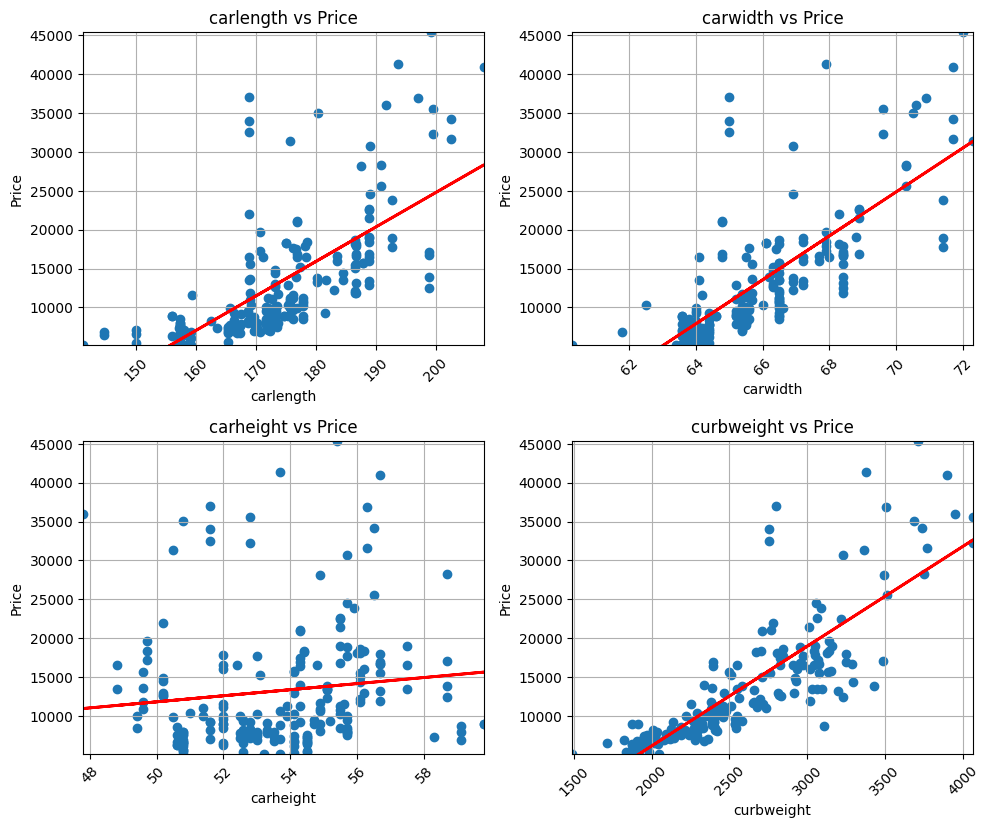

In [24]:
def scatter(x,fig):
    plt.subplot(5,2,fig)
    plt.scatter(cars[x],cars['price'])
    # Draw a line of best fit
    z = np.polyfit(cars[x], cars['price'], 1) # Fit a linear regression line to the data
    p = np.poly1d(z) # Create a polynomial function from the coefficients
    plt.plot(cars[x], p(cars[x]), color='red', linewidth=2) # Plot the line of best fit
    plt.xlim(cars[x].min(), cars[x].max()) # Set the x-axis limits to the minimum and maximum values of the column
    plt.ylim(cars['price'].min(), cars['price'].max()) # Set the y-axis limits to the minimum and maximum values of the 'price' column
    plt.title(f'{x} vs Price') # Set the title for the scatter plot
    plt.xlabel(x) # Set the x-axis label for the scatter plot
    plt.ylabel('Price') # Set the y-axis label for the scatter plot
    plt.xticks(rotation=45) # Rotate the x-axis labels for better readability
    plt.tight_layout() # Adjust the layout to prevent overlap of subplots
    plt.grid(True) # Add grid lines to the scatter plot for better readability
    plt.tight_layout() # Adjust the layout to prevent overlap of subplots
    plt.subplots_adjust(top=0.85) # Adjust the top margin to make space for the main title

plt.figure(figsize=(10,20))

scatter('carlength', 1)
scatter('carwidth', 2)
scatter('carheight', 3)
scatter('curbweight', 4)

plt.tight_layout()

#### Inference :

1. `carwidth`, `carlength` and `curbweight` seems to have a positive correlation with `price`.
2. `carheight` doesn't show any significant trend with price.

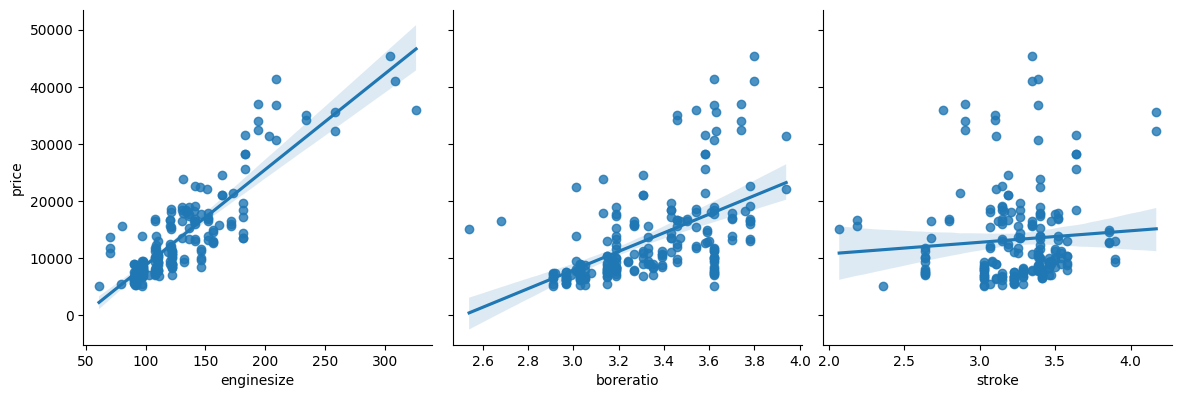

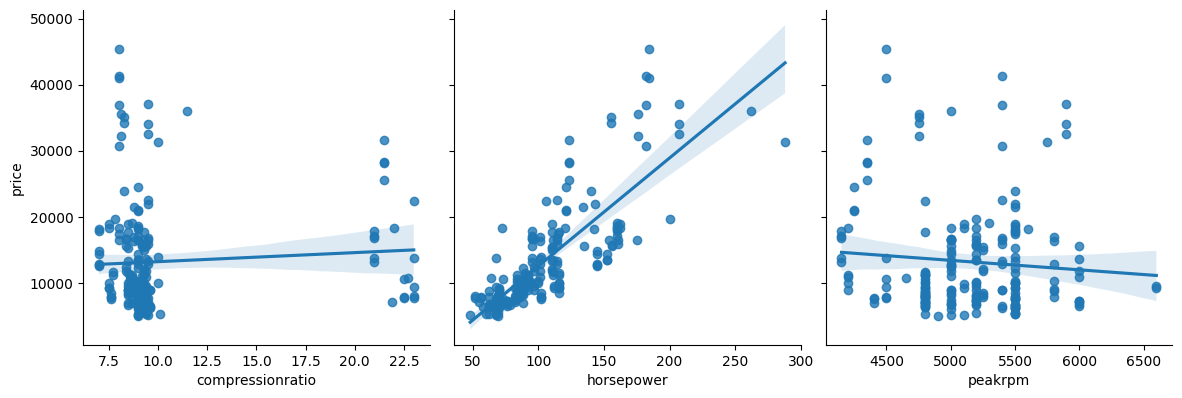

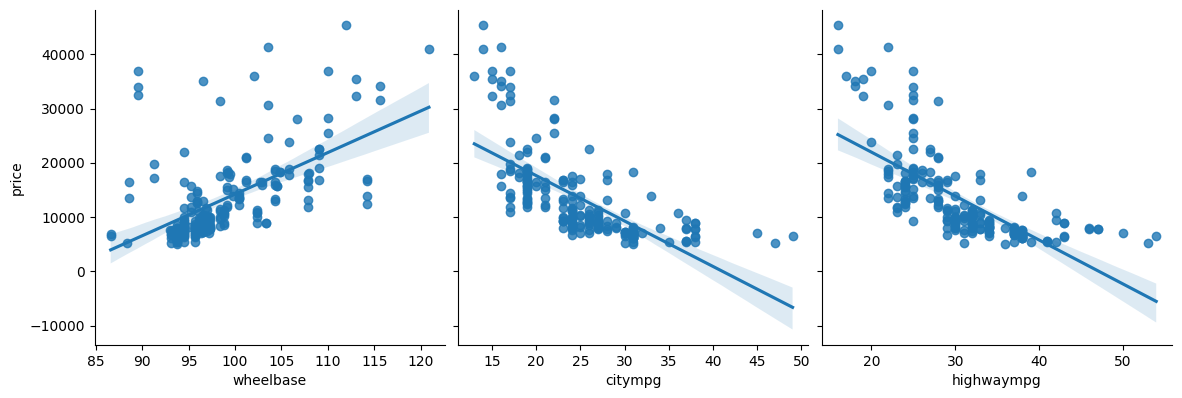

In [25]:
def pp(x,y,z):
    sns.pairplot(cars, x_vars=[x,y,z], y_vars='price',size=4, aspect=1, kind='reg')
    plt.show()

pp('enginesize', 'boreratio', 'stroke')
pp('compressionratio', 'horsepower', 'peakrpm')
pp('wheelbase', 'citympg', 'highwaympg')

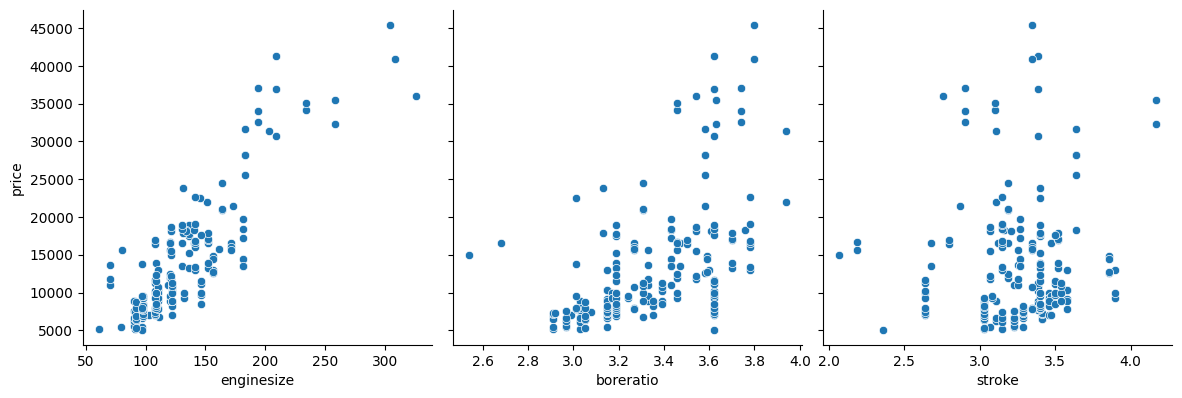

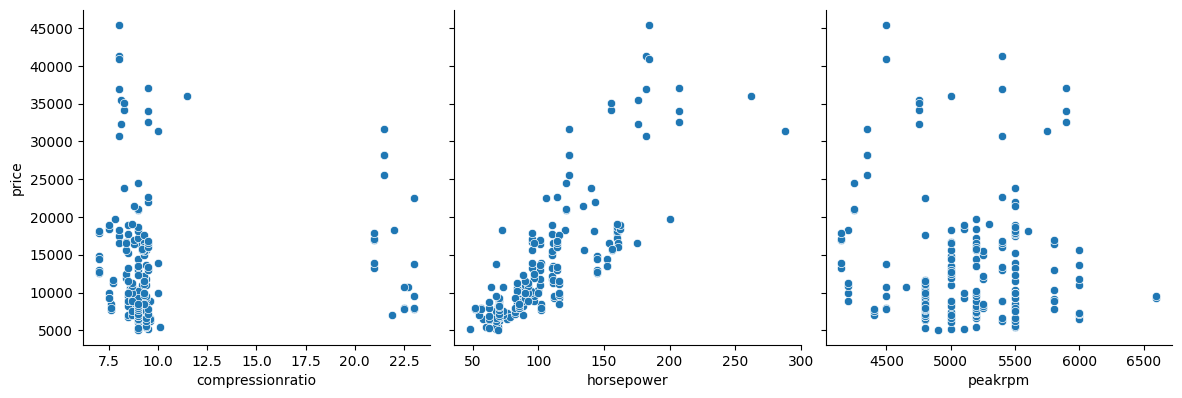

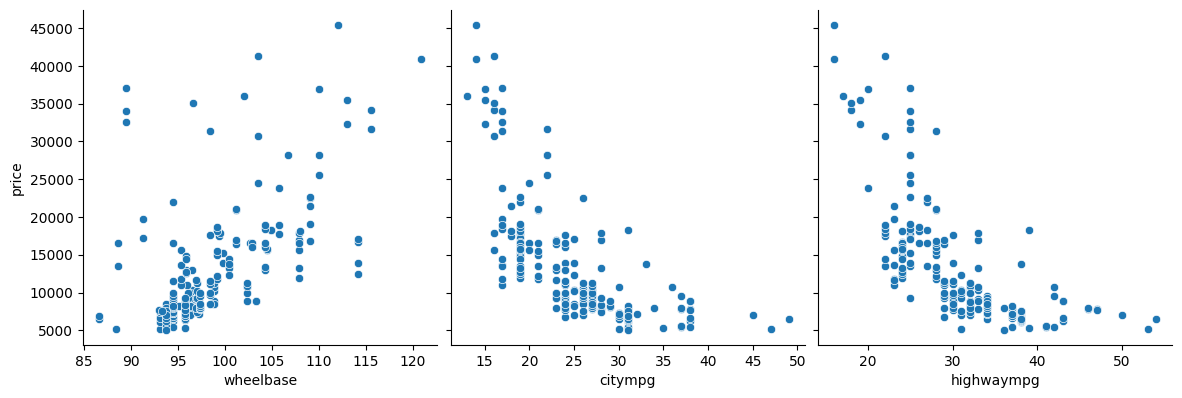

In [26]:
def pp(x,y,z):
    sns.pairplot(cars, x_vars=[x,y,z], y_vars='price',size=4, aspect=1, kind='scatter')
    plt.show()

pp('enginesize', 'boreratio', 'stroke')
pp('compressionratio', 'horsepower', 'peakrpm')
pp('wheelbase', 'citympg', 'highwaympg')